In [1]:
import pandas as pd
import numpy as np
import config
import utils
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import shap
import joblib

In [2]:
#random state 
rs = 7919

# Load data
df_com = pd.read_csv("../data/data_communities.csv", index_col=[0])
df = pd.read_csv(config.FEATS_PATH, header=None)
#df_labels = pd.read_csv(config.LABELS_PATH)
df = df.merge(df_com, left_on=0, right_on="txId").drop(["txId"], axis=1)
df.loc[:, "target"] = df[1]

/tmp/ipykernel_4707/3058764967.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.loc[:, "target"] = df[1]


In [3]:
feats_auc = pd.DataFrame(columns=["feature", "auc"])
for feat in range(1, 167):
    auc = utils.pred_power(feat, "label", df.loc[~df.loc[:, "label"].isnull()])
    feats_auc.loc[len(feats_auc)] = [feat, auc]

In [4]:
# let's only keep the most powerful features and remove the correlated ones
# also, add the graph features
features_to_keep = utils.filter_corr(df.loc[~df.loc[:, "label"].isnull(), :], feats_auc, thr=0.5)
features_to_keep.extend(["n_nodes", "n_illicit", "n_licit", "n_br"])

In [5]:
# Create X and y
X = df.loc[df.loc[:, "label"].notnull(), features_to_keep]
y = df.loc[df.loc[:, "label"].notnull(), "label"]
X.columns = X.columns.astype(str)

Everything is ready, we try two approaches a simple one and a complex one. A decision tree and an xgboost.

In [6]:
# full grid search CV with a decision tree
param_grid_tree = {
    "max_depth": [3, 5, 7],
    "min_samples_split": [5, 10, 20]
}

grid_search_tree = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=rs), # prime number
    param_grid=param_grid_tree,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=rs), 
    scoring="roc_auc"
)
grid_search_tree.fit(X, y)

print(grid_search_tree.best_score_)

0.9755978691098715


In [7]:
param_grid_xgb = {
    "max_depth": [2, 4, 6],
    "learning_rate": [0.01, 0.1, 0.3],
    "n_estimators": [20, 50],
    "subsample": [0.5, 1]
}

grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=rs, eval_metric="logloss"),
    param_grid=param_grid_xgb,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=rs),
    scoring="roc_auc",
    n_jobs=-1
)
grid_search_xgb.fit(X, y)
print(grid_search_xgb.best_score_)

0.9968096683061815


XGBoost wins, so we choose that model. We use cross validation which is a way to approximate the true error of the model, so no need to do anything else.

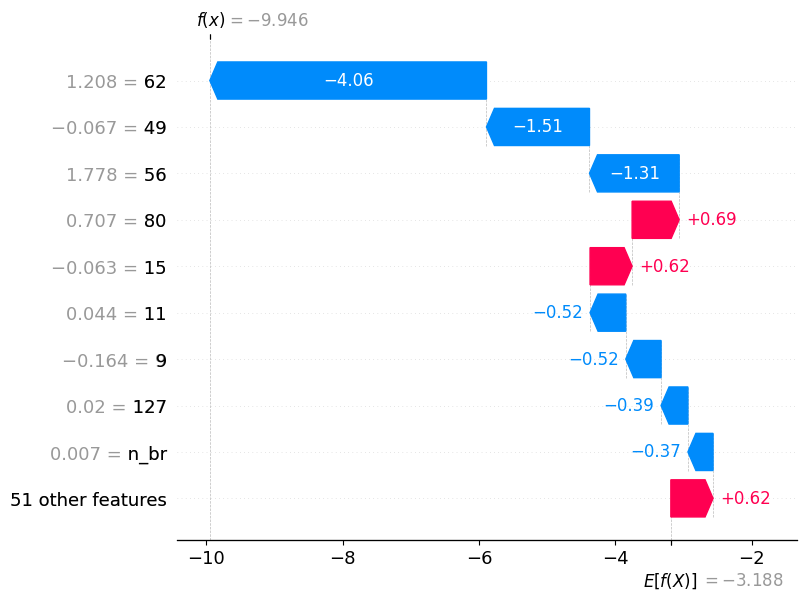

In [8]:
# Create explainer object
explainer = shap.TreeExplainer(grid_search_xgb.best_estimator_)
shap_values = explainer(X)
shap.waterfall_plot(shap_values[0])

In [9]:
pd.DataFrame.from_dict(grid_search_xgb.best_estimator_.get_booster().get_score(importance_type="gain"), orient="index", columns=["gain"]).sort_values("gain", ascending=False).head(6)

,gain
15,959.979370
56,181.036438
n_br,109.979645
161,75.442329
77,43.703972
62,39.594921


At least one of the graph features was in the top 5.

Now let's save the model and save the inferences

In [11]:
joblib.dump(grid_search_xgb.best_estimator_, "model.pkl")

['model.pkl']

In [12]:
# select the rows that we didnt use
X_new = df.loc[df.loc[: ,"label"].isnull(), features_to_keep]
X_new.columns = X_new.columns.astype(str)
ids = df.loc[df.loc[:, "label"].isnull(), [0]]
ids['pred'] = grid_search_xgb.best_estimator_.predict_proba(X_new)[:, 1]

In [13]:
#save as a csv
ids.to_csv("../data/inferences.csv")